In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:43265")
client

<Client: 'tcp://127.0.0.1:43265' processes=8 threads=32, memory=503.70 GiB>

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist
from xgcm.grid import Grid
import gsw

import rioxarray
import seaborn as sns
import xrft

import glob

import gcm_filters

import os.path as op

from scipy.interpolate import griddata, interpn

import warnings
warnings.filterwarnings("ignore")

# from xeofs.models import EOF
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.mrcosts import mrCOSTS
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_eigs, plot_summary

from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [3]:
grav = 9.807
meth = "linear"
ddir = "/storage/tartar/takaya/swot/"

In [4]:
ipass = 3
ds03 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % ipass))
ds03.coords["num_lines"] = ("num_lines",range(len(ds03.num_lines)))
ds03.coords["num_pixels"] = ("num_pixels",range(len(ds03.num_pixels)))
ds03

<xarray.Dataset> Size: 582MB
Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
Coordinates:
  * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
  * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
    latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
    longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
Data variables:
    ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>

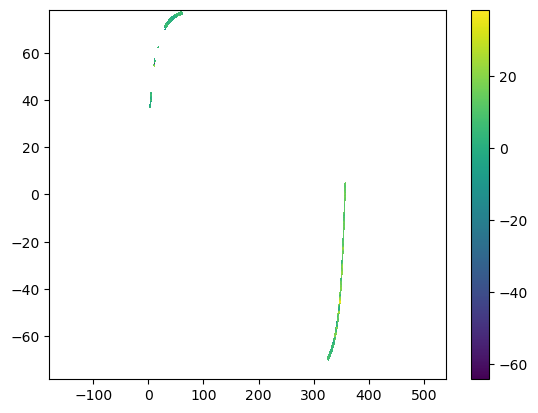

In [5]:
fig, ax = plt.subplots()
im = ax.pcolor(ds03.longitude, ds03.latitude,
          ds03.ssha_detided.isel(cycle_num=1), 
          rasterized=True
         )
fig.colorbar(im)
plt.show()

In [6]:
inp = 3

In [7]:
maskn = xr.DataArray(ds03.latitude.where(ds03.latitude>5.).to_masked_array().mask,
                     dims=ds03.latitude.dims,
                     coords=ds03.latitude.coords
                    )
masks = xr.DataArray(ds03.latitude.where(ds03.latitude<-5.).to_masked_array().mask,
                     dims=ds03.latitude.dims,
                     coords=ds03.latitude.coords
                    )
dsns = ds03.where(~maskn,drop=True)
dsns = xr.concat([dsns, ds03.where(~masks,drop=True)
                 ], "num_lines"
                ).sortby("num_lines")
dsns

<xarray.Dataset> Size: 550MB
Dimensions:       (cycle_num: 105, num_lines: 9312, num_pixels: 69)
Coordinates:
  * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines     (num_lines) int64 74kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
  * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
    latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4656, 69), meta=np.ndarray>
    longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4656, 69), meta=np.ndarray>
Data variables:
    ssha_detided  (cycle_num, num_lines, num_pixels) float64 540MB dask.array<chunksize=(1, 4656, 69), meta=np.ndarray>

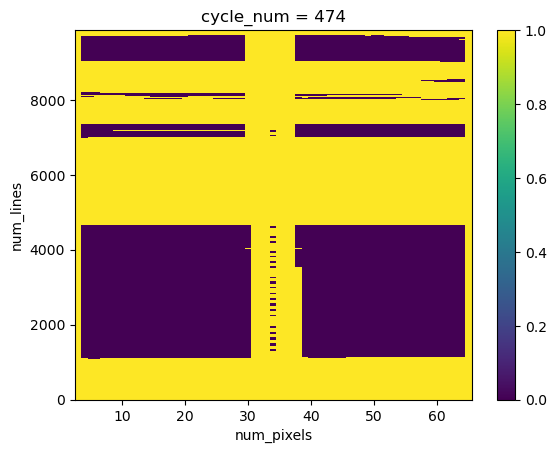

In [8]:
mask03 = xr.DataArray(dsns.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                     coords=dsns.ssha_detided.isel(cycle_num=0).coords
                    )
mm03 = xr.DataArray(mask03.where(mask03<.5
                              ).to_masked_array().mask,
                   dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                   coords=dsns.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm03.plot(rasterized=True)

In [9]:
r_ref = (~mm03).sum() / np.prod(mm03.shape)
r_ref

<xarray.DataArray ()> Size: 8B
array(0.42256961)
Coordinates:
    cycle_num  int64 8B 474

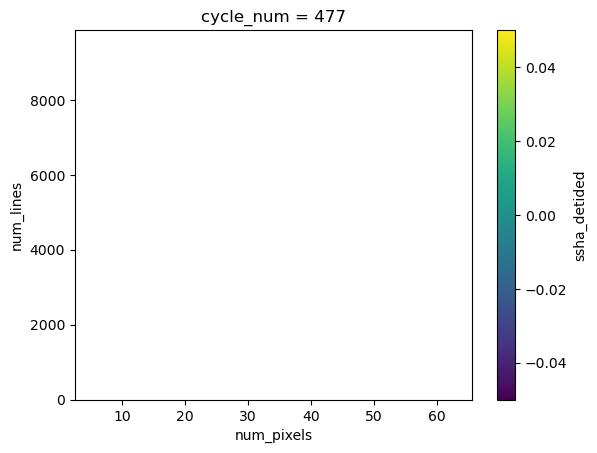

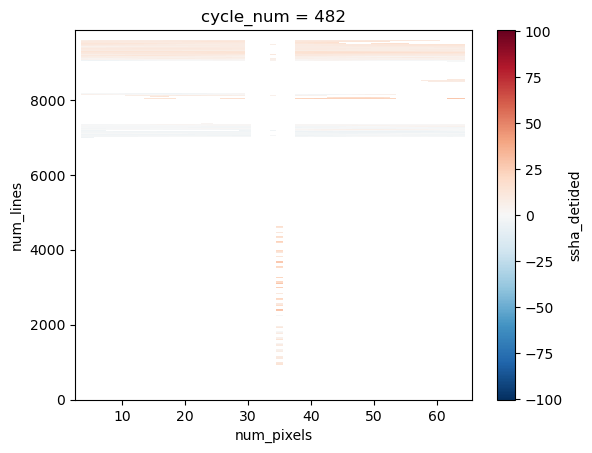

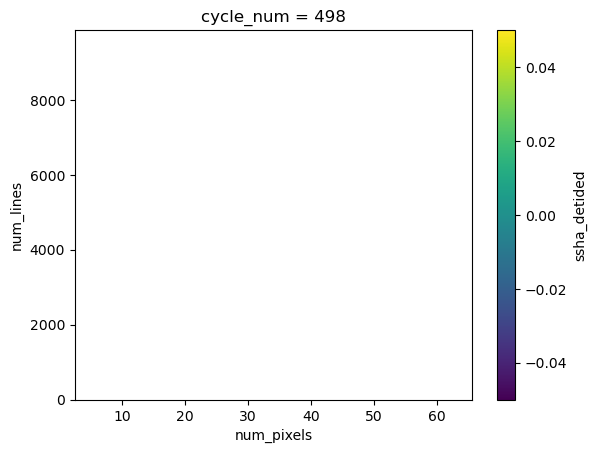

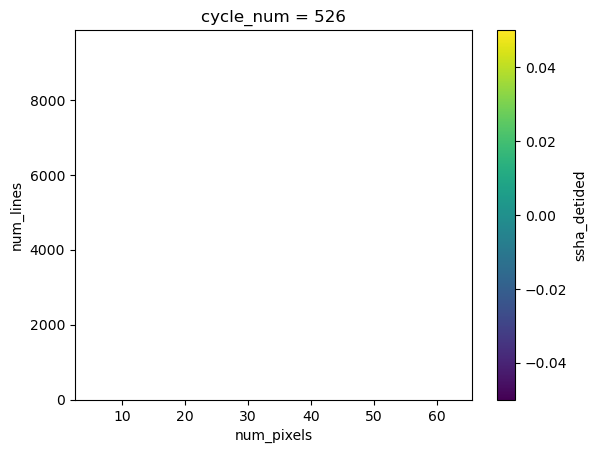

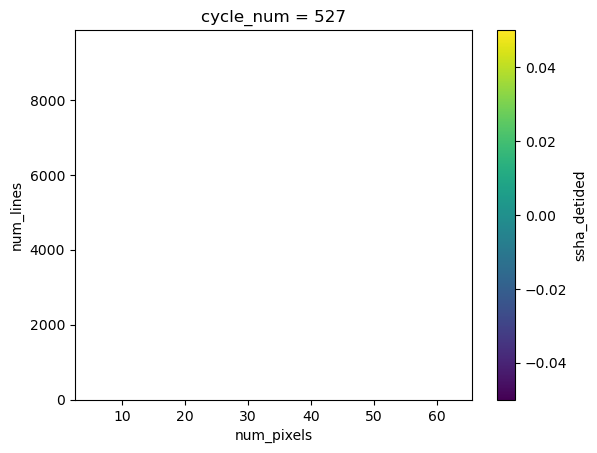

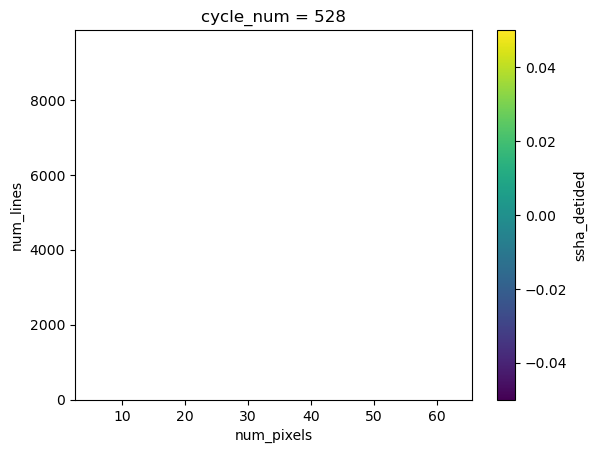

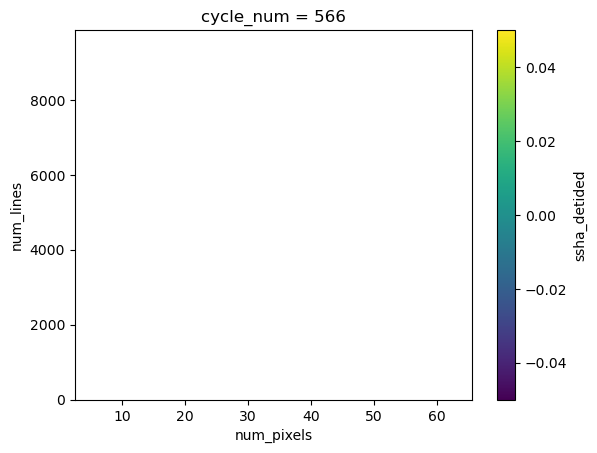

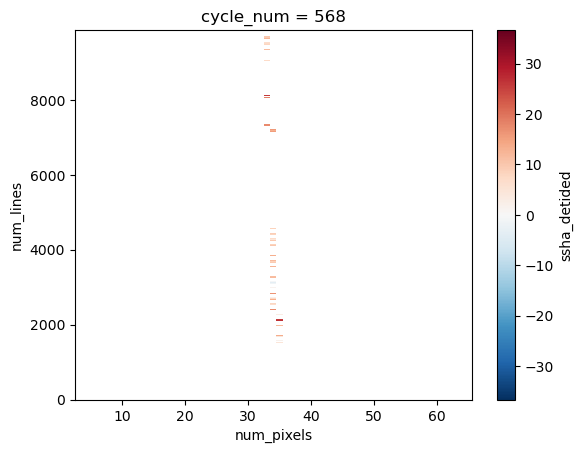

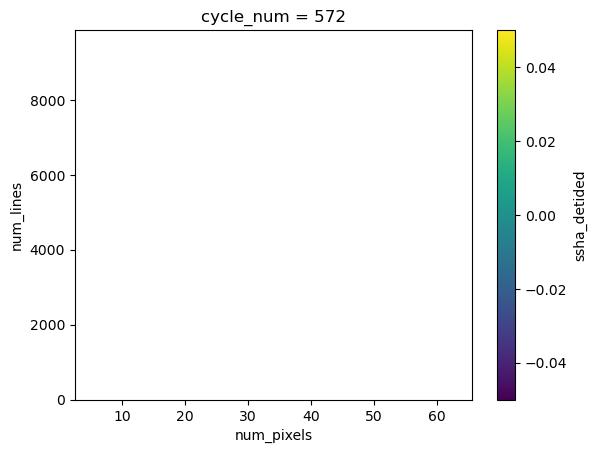

<xarray.DataArray 'ssha_detided' (cycle_num: 96, num_lines: 9312, num_pixels: 63)> Size: 451MB
dask.array<concatenate, shape=(96, 9312, 63), dtype=float64, chunksize=(1, 4656, 63), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 768B 474 475 476 478 479 ... 575 576 577 578
  * num_lines   (num_lines) int64 74kB 0 1 2 3 4 5 ... 9855 9856 9857 9858 9859
  * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
    latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4656, 63), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4656, 63), meta=np.ndarray>

In [10]:
ic = 0
for cc in dsns.cycle_num:
    
    ssha = dsns.ssha_detided.sel(cycle_num=cc).isel(num_pixels=slice(inp,-inp))
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        R03 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        R03 = xr.concat([R03, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref:
        if ic == 0:
            H03 = ssha
        else:
            try:
                H03 = xr.concat([H03, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    else:
        ssha.plot(rasterized=True)
        plt.show()
    del ssha, mask, array

H03.coords["cycle_num"] = ("cycle_num",
                           R03.where(R03>0.7*r_ref, drop=True).cycle_num.data
                          )
H03

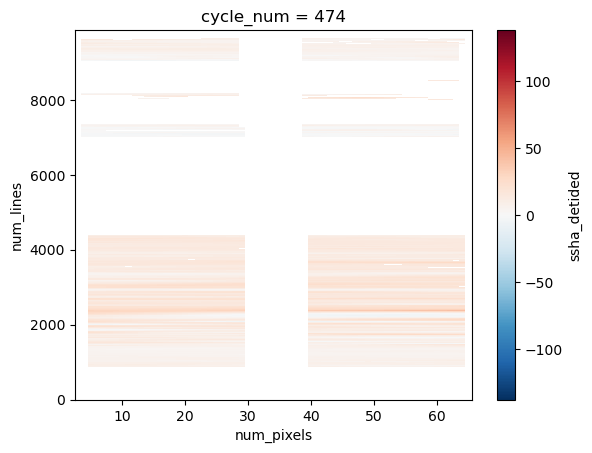

In [11]:
H03.isel(cycle_num=0).plot(rasterized=True)

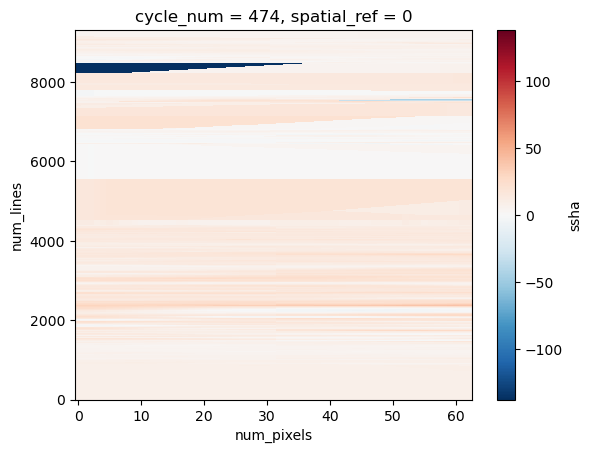

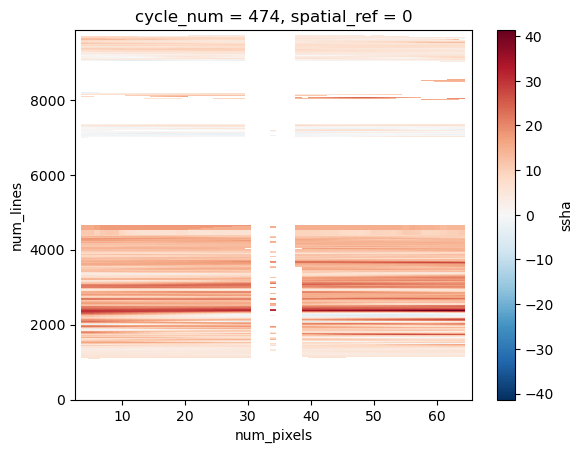

In [12]:
dsH03 = H03.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsH03.coords["y"] = ("y",range(len(dsH03.y)))
dsH03.coords["x"] = ("x",range(len(dsH03.x)))
if not dsH03.rio.crs:
    dsH03 = dsH03.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsH03.ssha.rio.nodata is None:
    dsH03["ssha"] = dsH03.ssha.rio.write_nodata(np.nan)
_H03_exterp = dsH03.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha
_H03_exterp.isel(cycle_num=0).plot(rasterized=True)
plt.show()

H03_exterp = _H03_exterp.where(mm03!=1)
H03_exterp.isel(cycle_num=0).plot(rasterized=True)
plt.show()

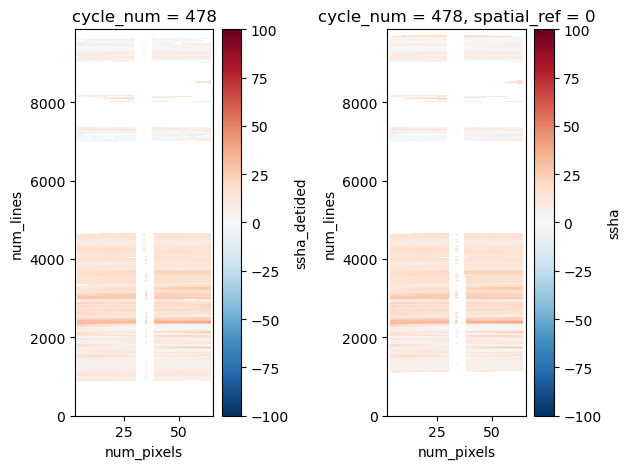

In [13]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
fig.set_tight_layout(True)

dsns.ssha_detided.sel(cycle_num=478
                     ).isel(num_pixels=slice(inp,-inp)
                           ).plot(ax=ax1, rasterized=True, vmax=1e2)
H03_exterp.sel(cycle_num=478).plot(ax=ax2, rasterized=True, vmax=1e2)

In [14]:
fscale = np.ceil(14/np.sqrt(12)/2)
print(fscale)

3.0


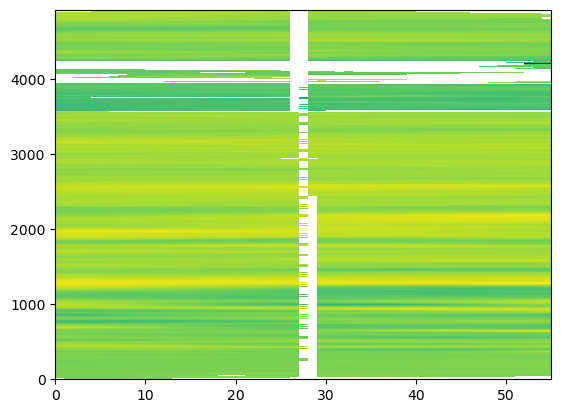

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 9310, num_pixels: 61)> Size: 477MB
 dask.array<mul, shape=(105, 9310, 61), dtype=float64, chunksize=(105, 776, 7), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 4919, num_pixels: 55)> Size: 227MB
 dask.array<where, shape=(105, 4919, 55), dtype=float64, chunksize=(105, 775, 6), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 39kB 1094 1095 109

In [15]:
h_interp = xr.open_zarr(op.join(ddir,
                        'CalVal/Pass%03d/ssha_rawgrid_%02dpoints.zarr' 
                        % (ipass,fscale))
                       ).ssha.interp(cycle_num=ds03.cycle_num, 
                                     method="slinear",
                                     kwargs={"fill_value": "extrapolate"}
                                    ) * 1e-2   # centimeters to meters
# h_interp.coords["num_pixels"] = ("num_pixels", range(len(h_interp.num_pixels)))
# h_interp.coords["num_lines"] = ("num_lines", range(len(h_interp.num_lines)))
# maskh = xr.DataArray(h_interp.to_masked_array().mask,
#                      dims=h_interp.dims, coords=h_interp.coords
#                     )
h_dropped = h_interp.where(mm03.isel(num_pixels=slice(1,-1),
                                     num_lines=slice(1,-1)
                                    ).reset_coords(drop=True)!=1, drop=True)

plt.pcolormesh(h_dropped.isel(cycle_num=10).data,rasterized=True)
plt.show()
h_interp, h_dropped

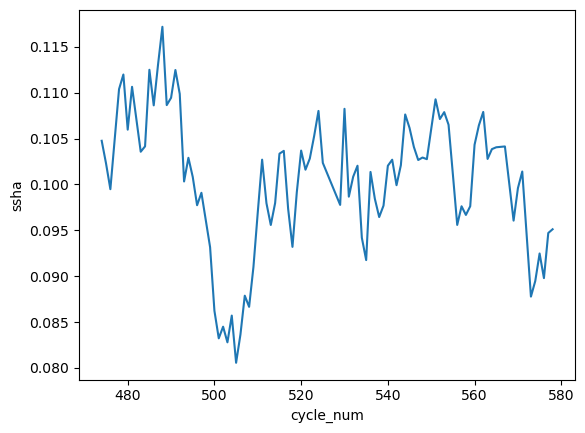

In [16]:
h_dropped.mean(['num_lines','num_pixels'],skipna=True).plot()

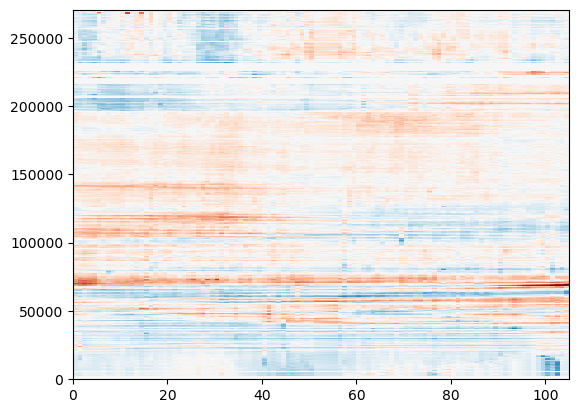

<xarray.DataArray 'ssha' (z: 270545, cycle_num: 105)> Size: 227MB
dask.array<transpose, shape=(270545, 105), dtype=float64, chunksize=(10000, 105), chunktype=numpy.ndarray>
Coordinates:
  * z           (z) object 2MB MultiIndex
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
    latitude    (z) float64 2MB dask.array<chunksize=(10000,), meta=np.ndarray>
    longitude   (z) float64 2MB dask.array<chunksize=(10000,), meta=np.ndarray>
  * num_lines   (z) int64 2MB 1094 1094 1094 1094 1094 ... 9722 9722 9722 9722
  * num_pixels  (z) int64 2MB 4 5 6 7 8 9 10 11 12 ... 57 58 59 60 61 62 63 64

In [17]:
zchunk = 10000
h_stacked = (h_dropped 
             - h_dropped.mean(['num_lines','num_pixels'],skipna=True)
            ).stack(z=('num_lines','num_pixels')
                          ).chunk({'z':zchunk}).fillna(0.)
# h_stacked = h_interp.stack(z=("YC", "XC")
#                           ).chunk({'z':zchunk}).fillna(0.)

fig, ax = plt.subplots()
ax.pcolormesh(h_stacked.T.values, 
              rasterized=True,  
              vmax=.4, vmin=-.4, cmap='RdBu_r')
plt.show()
h_stacked.T

In [18]:
nh = 24.*3600.
window_lengths = np.ceil( np.array([9, 10, 30, 60])
                         * 86400/nh ).astype(int) # 24 hourly
step_sizes = np.array([1, 1, 1, 1])
print(window_lengths, "[days]")
nh / 86400.

[ 9 10 30 60] [days]


1.0

In [19]:
fit = False

In [ ]:
svd_ranks = [4, 4, 10, 12]
if len(svd_ranks) != len(window_lengths):
    print("######### WRONG LENGTHS #########")
suppress_growth = True
transform_method = "absolute"
# n_components_array = [2] * len(window_lengths)
global_svd_array = [False] * len(window_lengths)
# kern_method = "flat"
# real_eig_limit = 0.5
# pydmd_kwargs = {
#     "eig_constraints": {"conjugate_pairs", "limited"},
#     "real_eig_limit": real_eig_limit,
# }

dmd = mrCOSTS(
    svd_rank_array=svd_ranks,
    window_length_array=window_lengths,
    step_size_array=step_sizes,
    global_svd_array=global_svd_array,
    cluster_sweep=True,
    transform_method=transform_method,
    # kern_method=kern_method,
    # relative_filter_length=relative_filter_length,
    # pydmd_kwargs=pydmd_kwargs,
)

if fit:
    dmd.fit(h_stacked.values.T, 
            np.atleast_2d(np.arange(len(h_stacked.cycle_num)
                                   ) * nh)
           )

_________________________________________________
Fitting window length = 9
0 of 97


In [20]:
if fit:
    # dmd.to_netcdf(op.join(ddir, 
    #                       "SWOT/CalVal/mrCOSTS_h/%02dhourly/%02d_fit"
    #                       % (nh,len(window_lengths))
    #                      )
    #              )
    dmd.to_netcdf(op.join(ddir, 
                  "CalVal/mrCOSTS/Pass%03d_%02d_raw_%02dpoints"
                  % (ipass,len(window_lengths),2)
                         )
                 )
else:
    mrc = glob.glob(op.join(ddir, 
                "CalVal/mrCOSTS/Pass%03d_04_raw_*.nc"
                % (ipass)
                           )
                   )
    print(mrc)
    dmd = mrCOSTS()
    dmd.from_netcdf(mrc)

['/storage/tartar/takaya/swot/CalVal/mrCOSTS/Pass003_04_raw_03points.window=9.nc', '/storage/tartar/takaya/swot/CalVal/mrCOSTS/Pass003_04_raw_03points.window=10.nc', '/storage/tartar/takaya/swot/CalVal/mrCOSTS/Pass003_04_raw_03points.window=30.nc', '/storage/tartar/takaya/swot/CalVal/mrCOSTS/Pass003_04_raw_03points.window=60.nc']


In [21]:
dmd.multi_res_interp()
dmd._da_omega

<xarray.DataArray 'omega' (window_length: 4, window_time_means: 97, svd_rank: 12)> Size: 74kB
array([[[            nan           +nanj,
                     nan           +nanj,
         -1.03525722e-07+1.82938741e-05j, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        [            nan           +nanj,
                     nan           +nanj,
         -3.48283360e-07+1.86328053e-05j, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        [            nan           +nanj,
                     nan           +nanj,
         -2.78298836e-07+1.84356339e-05j, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        ...,
        [            nan           +nanj,
...
                     nan           +nanj],
        ...,
        [            nan           +nanj,
                     nan           +nanj,
                     nan           +nanj, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        [            nan           +nanj,
                     nan           +nanj,
                     nan           +nanj, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        [            nan           +nanj,
                     nan           +nanj,
                     nan           +nanj, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj]]], shape=(4, 97, 12))
Coordinates:
  * window_length        (window_length) int64 32B 9 10 30 60
  * window_time_means    (window_time_means) float64 776B 3.456e+05 ... 8.64e+06
  * svd_rank             (svd_rank) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
    slide                (window_length, window_time_means) float64 3kB 0.0 ....
    decomposition_level  (window_length) int64 32B 0 1 2 3

fitting n_components = 4
fitting n_components = 5
fitting n_components = 6
fitting n_components = 7
fitting n_components = 8
fitting n_components = 9
fitting n_components = 10
fitting n_components = 11
fitting n_components = 12
fitting n_components = 13
fitting n_components = 14
fitting n_components = 15
fitting n_components = 16
fitting n_components = 17
fitting n_components = 18
fitting n_components = 19
fitting n_components = 20
fitting n_components = 21
fitting n_components = 22
fitting n_components = 23
fitting n_components = 24
fitting n_components = 25
fitting n_components = 26
fitting n_components = 27
fitting n_components = 28
fitting n_components = 29
Optimal silhouette score is = 9


Text(0, 0.5, 'Silhouette score (-), (1 is best, -1 is worst)')

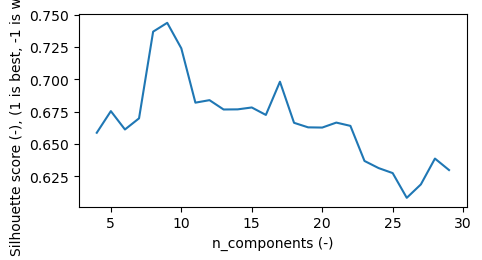

In [22]:
n_components_range = np.arange(4, 30)
scores, n_optimal = dmd.global_cluster_hyperparameter_sweep(
    n_components_range,
    transform_method="log10",
)

print("Optimal silhouette score is = {}".format(n_optimal))
plt.figure(figsize=(5, 2.5))
plt.plot(n_components_range, scores)
plt.gca().set_xlabel("n_components (-)")
plt.gca().set_ylabel("Silhouette score (-), (1 is best, -1 is worst)")

In [23]:
# n_ops = 10
cluster_centroids, omega_classes, omega_array = dmd.global_cluster_omega(
    n_optimal,
    # n_ops,
    transform_method="log10"
)
cluster_centers_periods = 1 / (10 ** (cluster_centroids) / (2 * np.pi))

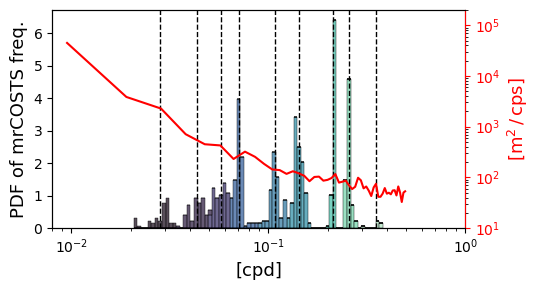

In [24]:
x_trans = (2 * np.pi / 10**omega_array / 86400.)**-1

hue_order = np.arange(len(np.unique(omega_classes))).astype(str)
cluster_centers = 1 / ((10 ** cluster_centroids) / (2 * np.pi) / 86400.)

# Make a continuous color palette with the brightest and darkest excluded
palette = sns.color_palette("mako", len(cluster_centers) + 2)
# palette = palette[1:-1]


Fh = xrft.power_spectrum(h_dropped[...,::150,10::40
                         ].chunk({'cycle_num':-1}
                                ).assign_coords({'cycle_num':
                                                 np.arange(len(h_interp.cycle_num)) 
                                                 * nh}
                                               ), 
                         dim='cycle_num', window='hann', window_correction=True
                        ).astype(np.single)

from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(5.5, 3))
ax2 = ax.twinx()
fig.set_tight_layout(True)

ax2.plot(Fh.freq_cycle_num.isel(freq_cycle_num=slice(len(Fh.freq_cycle_num)//2+1,None)
                               )*86400, 
         Fh.isel(freq_cycle_num=slice(len(Fh.freq_cycle_num)//2+1,None)
                ).mean(['num_pixels','num_lines'],skipna=True)*2,
         c='r', label=r"Fourier")

ax.set_xscale("log")
ax2.set_yscale("log")

sns.histplot(
    # x=((10**omega_array) / (2 * np.pi) / 86400.),
    x=x_trans,
    hue=omega_classes,
    hue_order=hue_order,
    common_bins=True,
    common_norm=True,
    stat="density",
    multiple="stack",
    bins=70,
    palette=ListedColormap(palette),
    legend=False,
    ax=ax
)

ax.set_xlabel(r"[cpd]", fontsize=13)
ax.set_ylabel("PDF of mrCOSTS freq.", fontsize=13)
ax2.set_ylabel("[m$^2\,/\,$cps]", fontsize=13, c='r')

ax.set_xlim([8e-3,1e0])
# ax2.set_xlim([8e-3,1.5e1])
ax2.set_ylim([1e1,2e5])

ax2.spines['right'].set_color('red')
ax2.tick_params(axis='y', colors='red')

[
    ax.axvline((2 * np.pi / (10**c) / 86400)**-1, color="k", ls="--", lw=1)
    for nc, c in enumerate(cluster_centroids)
];

plt.savefig(op.join(ddir,'../Figs/SWOT_Pass%03d-raw_mrCOSTS_hist-%02d_%02dpoints.pdf' 
                    % (ipass,len(window_lengths),int(fscale)))
           )

In [25]:
np.where((2 * np.pi / (10**cluster_centroids) 
          / 86400)**-1 <= 1e-1)

(array([0, 1, 2, 3]),)

In [26]:
omega_classes_list = dmd.multi_res_deterp()

In [27]:
xr_background = dmd.get_background()
print(xr_background.shape, h_stacked)

ds_global_background = xr.DataArray(xr_background, dims=h_stacked.T.dims,
                            coords=h_stacked.T.coords
                           ).unstack().chunk({'cycle_num':1}
                                            ).interp(
    num_pixels=mm03.drop("cycle_num").isel(num_pixels=slice(1,-1)).num_pixels,
    num_lines=mm03.drop("cycle_num").isel(num_lines=slice(1,-1)).num_lines
                                            ).where(mm03.isel(num_pixels=slice(1,-1),
                                                              num_lines=slice(1,-1)
                                                             )!=1
                                                   )
ds_global_background.chunk(
        {'num_pixels':-1, 'num_lines':-1}
).to_dataset(name='background'
            ).to_zarr(op.join(ddir,
            'CalVal/Pass%03d/background-raw_%02dpoints.zarr' 
                              % (ipass, fscale)),
                              mode='w')

(270545, 105) <xarray.DataArray 'ssha' (cycle_num: 105, z: 270545)> Size: 227MB
dask.array<where, shape=(105, 270545), dtype=float64, chunksize=(105, 10000), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * z           (z) object 2MB MultiIndex
    latitude    (z) float64 2MB dask.array<chunksize=(10000,), meta=np.ndarray>
    longitude   (z) float64 2MB dask.array<chunksize=(10000,), meta=np.ndarray>
  * num_lines   (z) int64 2MB 1094 1094 1094 1094 1094 ... 9722 9722 9722 9722
  * num_pixels  (z) int64 2MB 4 5 6 7 8 9 10 11 12 ... 57 58 59 60 61 62 63 64


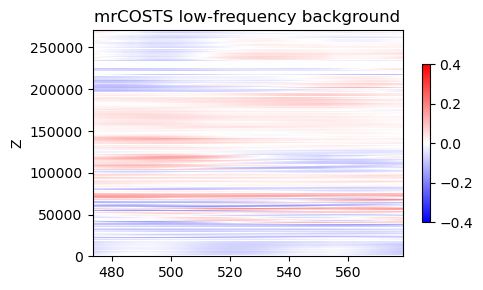

In [28]:
fig, ax = plt.subplots(figsize=(5, 3))
fig.set_tight_layout(True)
im = ax.pcolormesh(
    h_stacked.cycle_num,
    np.arange(len(h_stacked.z)), 
    xr_background, 
    vmin=-.4, vmax=.4, cmap="bwr",
    rasterized=True
)
ax.set_title("mrCOSTS low-frequency background")
ax.set_ylabel("Z")
# fig.autofmt_xdate()
fig.colorbar(im, shrink=.7)

In [29]:
xr_sep = dmd.global_scale_reconstruction()

In [30]:
for ncl_center, cl_center in enumerate(cluster_centers_periods):
    
    ds_xr_sep = xr.DataArray(
        xr_sep.real[:, ncl_center],
        dims=["decomp_level", "z", "cycle_num"],
        coords=[
            np.arange(len(dmd.costs_array)),
            # np.arange(n_optimal),
            h_stacked.z,
            h_stacked.cycle_num,
        ],
    )
    
    for dd in ds_xr_sep.decomp_level:
        if dd == 0:
            sep_unstacked = ds_xr_sep.sel(decomp_level=dd
                                 ).unstack().chunk({'cycle_num':1})
        else:
            tmp = ds_xr_sep.sel(decomp_level=dd
                               ).unstack().chunk({'cycle_num':1})
            sep_unstacked = xr.concat([sep_unstacked,
                                       tmp
                                      ], 'decomp_level'
                                     )
            del tmp

    ds_global_separation = sep_unstacked.interp(
        num_pixels=mm03.drop("cycle_num").isel(num_pixels=slice(1,-1)).num_pixels,
        num_lines=mm03.drop("cycle_num").isel(num_lines=slice(1,-1)).num_lines
                                               ).where(mm03.isel(num_pixels=slice(1,-1),
                                                                 num_lines=slice(1,-1)
                                                                )!=1
                                                      )

    ds_cluster_centers = xr.DataArray(
        np.array([1 / (10 ** (cluster_centroids[ncl_center]) / (2 * np.pi)),]),
        dims=["cluster"],
        # coords=[np.arange(n_optimal)],
        coords=[np.array([ncl_center,])],
    )
    ds_cluster_centers.attrs["units"] = "s"
    ds_cluster_centers.attrs["long_name"] = "Central period of each period band"
    
    ds_global_separation = ds_global_separation.to_dataset(name="frequency_bands")
    ds_global_separation["frequency_bands"].attrs["units"] = "m"
    ds_global_separation["frequency_bands"].attrs["long_name"] = "mrCOSTS"
    
    ds_global_separation.coords["cluster_centers"] = ds_cluster_centers

    if ncl_center == 0:
        print(ds_global_separation)
        
    ds_global_separation.chunk(
                {'num_pixels':-1, 'num_lines':-1}
                ).to_zarr(op.join(ddir,
    'CalVal/Pass%03d/cluster%02d-raw_%02dpoints.zarr' 
                      % (ipass, ncl_center, fscale)),
                      mode='w')
    print(ncl_center)

<xarray.Dataset> Size: 2GB
Dimensions:          (decomp_level: 4, cycle_num: 105, num_pixels: 61,
                      num_lines: 9310, cluster: 1)
Coordinates:
  * decomp_level     (decomp_level) int64 32B 0 1 2 3
  * cycle_num        (cycle_num) int64 840B 474 475 476 477 ... 575 576 577 578
  * num_pixels       (num_pixels) int64 488B 4 5 6 7 8 9 ... 59 60 61 62 63 64
  * num_lines        (num_lines) int64 74kB 1 2 3 4 5 ... 9855 9856 9857 9858
  * cluster          (cluster) int64 8B 0
    latitude         (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4655, 61), meta=np.ndarray>
    longitude        (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4655, 61), meta=np.ndarray>
    cluster_centers  (cluster) float64 8B 3.058e+06
Data variables:
    frequency_bands  (decomp_level, cycle_num, num_lines, num_pixels) float64 2GB dask.array<chunksize=(1, 1, 9310, 61), meta=np.ndarray>
0
1
2
3
4
5
6
7
8


In [31]:
xr_global_reconstruction = dmd.global_reconstruction()
glb_unstacked = xr.DataArray(
    data=xr_global_reconstruction.real, 
    dims=h_stacked.T.dims,
    coords=h_stacked.T.coords
).unstack()

da_global_reconstruction = glb_unstacked.interp(
        num_pixels=mm03.drop("cycle_num").isel(num_pixels=slice(1,-1)).num_pixels,
        num_lines=mm03.drop("cycle_num").isel(num_lines=slice(1,-1)).num_lines
                                               ).where(mm03.isel(num_pixels=slice(1,-1),
                                                                 num_lines=slice(1,-1)
                                                                )!=1
                                                      )
da_global_reconstruction.attrs["units"] = "m"
da_global_reconstruction.attrs["long_name"] = r"SWOT SSH"

da_global_reconstruction.chunk(
    # {'lat':100, 'lon':100}
).to_dataset(name='SSH').to_zarr(op.join(ddir,
                    'CalVal/Pass%03d/Total-raw_%02dpoints.zarr' 
                      % (ipass, fscale)),
                      mode='w')

# Extract the slow component

In [24]:
for i in range(30):
    if i == 0:
        dsc = xr.open_zarr(op.join(ddir,
            'CalVal/Pass%03d/cluster%02d-raw_%02dpoints.zarr' 
                                    % (ipass,i,fscale))
                           )

    else:
        try:
            dsc = xr.concat([dsc,xr.open_zarr(op.join(ddir,
                    'CalVal/Pass%03d/cluster%02d-raw_%02dpoints.zarr' 
                                  % (ipass,i,fscale)))
                            ], 'cluster')

        except:
            pass
    
dsC = xr.open_zarr(op.join(ddir,
            'CalVal/Pass%03d/Total-raw_%02dpoints.zarr' 
                           % (ipass,fscale))
                  )

dsb = xr.open_zarr(op.join(ddir,
            'CalVal/Pass%03d/background-raw_%02dpoints.zarr' 
                           % (ipass,fscale))
                  )

dsc

<xarray.Dataset> Size: 17GB
Dimensions:          (cluster: 9, decomp_level: 4, cycle_num: 105,
                      num_lines: 9310, num_pixels: 61)
Coordinates:
  * cluster          (cluster) int64 72B 0 1 2 3 4 5 6 7 8
  * decomp_level     (decomp_level) int64 32B 0 1 2 3
  * cycle_num        (cycle_num) int64 840B 474 475 476 477 ... 575 576 577 578
  * num_lines        (num_lines) int64 74kB 1 2 3 4 5 ... 9855 9856 9857 9858
  * num_pixels       (num_pixels) int64 488B 4 5 6 7 8 9 ... 59 60 61 62 63 64
    cluster_centers  (cluster) float64 72B dask.array<chunksize=(1,), meta=np.ndarray>
    latitude         (num_lines, num_pixels) float64 5MB -77.13 -77.14 ... 77.13
    longitude        (num_lines, num_pixels) float64 5MB 273.3 273.3 ... 80.05
Data variables:
    frequency_bands  (cluster, decomp_level, cycle_num, num_lines, num_pixels) float64 17GB dask.array<chunksize=(1, 1, 1, 9310, 61), meta=np.ndarray>

In [25]:
try:
    low = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d_old/SSHa.zarr" 
                               % ipass)
                      ).ssha
except:
    n_cluster = len(np.where((2 * np.pi / (10**cluster_centroids) 
                              / 86400.)**-1 <= 1e-1)[0]
                   )
    print(n_cluster)
    low = (dsb.background 
           + dsc.frequency_bands.isel(cluster=slice(None,n_cluster)
                                     ).sum(['cluster','decomp_level'])
          ) + h_dropped.mean(['num_lines','num_pixels'],skipna=True)
    low.to_dataset(name="ssha").to_zarr(op.join(ddir,"CalVal/geos/Pass%03d_old/SSHa.zarr" 
                                                % ipass),
                                        mode="w")

tot = xr.open_zarr(op.join(ddir,
                   'CalVal/Pass%03d/Total-raw_%02dpoints.zarr' 
                   % (ipass,fscale))
                  ).SSH
low

4


<xarray.DataArray (cycle_num: 105, num_lines: 9310, num_pixels: 61)> Size: 477MB
dask.array<add, shape=(105, 9310, 61), dtype=float64, chunksize=(1, 9310, 61), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
  * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 5MB -77.13 -77.14 ... 77.13
    longitude   (num_lines, num_pixels) float64 5MB 273.3 273.3 ... 80.05 80.05

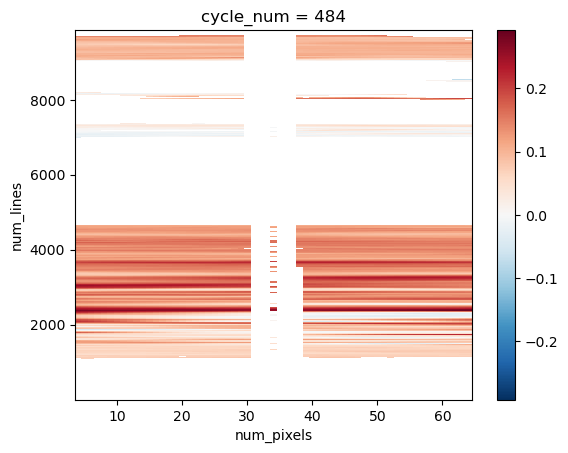

In [26]:
low.isel(cycle_num=10).plot(rasterized=True)

# Compute geostrophy

Recasting longitude.


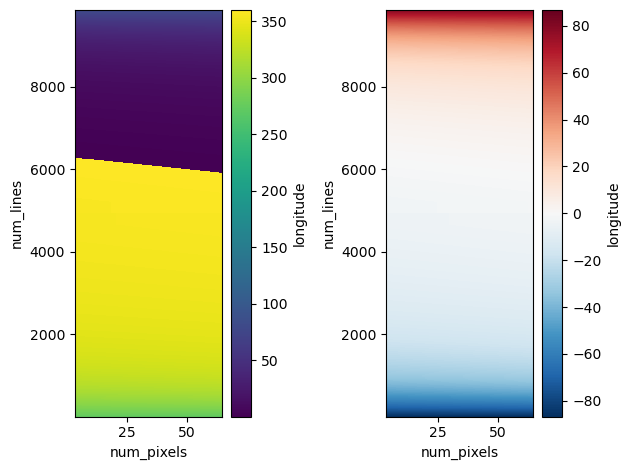

In [27]:
lati = low.latitude
longi = low.longitude
if (longi.max(skipna=True)-longi.min(skipna=True)) > 180.:
    print("Recasting longitude.")
    # long[long>180.] -=-360
    # long_values = long.values
    # long_values[long_values > 180.] -= 360.
    # long_adjusted = long.copy(data=long_values
    #                          ).where(mm01.isel(num_pixels=slice(1,-1), num_lines=slice(1,-1)
    #                                           )!=1, drop=True
    #                                 )
    # long_masked = xr.where(long > 180, long - 360, long)
    long_adjusted = xr.where(longi > 180, longi - 360, longi)
else:
    # long_masked = long.copy()
    long_adjusted = longi

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2)
fig.set_tight_layout(True)
longi.plot(ax=ax1)
long_adjusted.plot(ax=ax2)
# long_masked.plot(ax=ax3)

In [28]:
import sys
sys.path.append('../')
from SwotDiag.diagnosis import *

params = dict(derivative = 'fit', # Derivative obtained by the fitting method instead of point difference
          n = 5, # 5x5 point kernels
          min_valid_points = 0.75, # Ratio of valid points to compute the derivative (e.g. 75% valid points are necessary to compute the derivatives, useful to avoid boundary effects)
          cyclostrophy = 'GW', # Cyclogeostrophic currents are computed using the wind-gradient balance
          avoid_negative = True, # Parameter that avoid negative values in the SQRT using the GW formulation (leading to invalid values in the solutions)
          second_derivative = 'dxdy', # The second derivative is obtained by point-difference the first derivative (obtained by surface fitting method), rather than from the surface curvature. I noticed that it reduces the noise. 
          kernel = 'circular', # can be circular or a square, the shape of the kernel

)

## Diagnostics from original SSH
for cc in low.cycle_num:
    diag = compute_ocean_diagnostics_from_eta(low.sel(cycle_num=cc), 
                                          low.longitude, low.latitude, **params
                                             )
    if cc == low.cycle_num[0]:
        dsave = xr.DataArray(diag["ug"], dims=low.sel(cycle_num=cc).dims,
                             coords=low.sel(cycle_num=cc).coords
                            ).to_dataset(name='ug')
        dsave["vg"] = xr.DataArray(diag["vg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave["ucg"] = xr.DataArray(diag["ucg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave["vcg"] = xr.DataArray(diag["vcg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave["vort"] = xr.DataArray(diag["zeta"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave["strain"] = xr.DataArray(diag["S"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
    else:
        tmp = xr.DataArray(diag["ug"], dims=low.sel(cycle_num=cc).dims,
                             coords=low.sel(cycle_num=cc).coords
                            ).to_dataset(name='ug')
        tmp["vg"] = xr.DataArray(diag["vg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        tmp["ucg"] = xr.DataArray(diag["ucg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        tmp["vcg"] = xr.DataArray(diag["vcg"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        tmp["vort"] = xr.DataArray(diag["zeta"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        tmp["strain"] = xr.DataArray(diag["S"], dims=low.sel(cycle_num=cc).dims,
                                 coords=low.sel(cycle_num=cc).coords
                                )
        dsave = xr.concat([dsave, tmp], "cycle_num")
        del tmp

print(dsave)

dsave.chunk({"cycle_num":1}).to_zarr(op.join(ddir,
                                             "CalVal/geos/Pass%03d_old/SSVs_SwotDiag.zarr" 
                                          % ipass),
                                  mode="w")

TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library not available. Running without progress bar.
TQDM library n

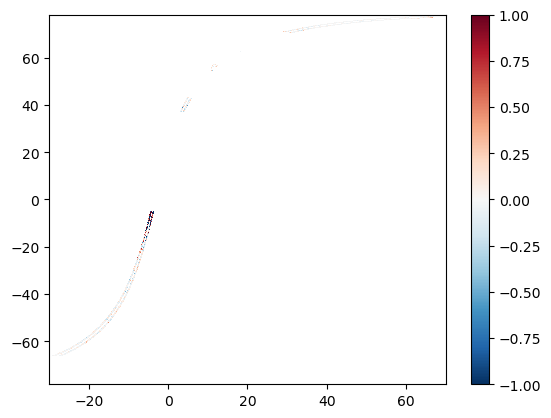

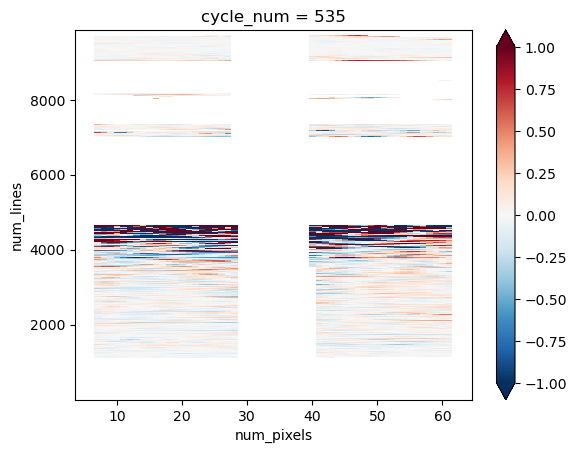

In [29]:
f = gsw.f(dsave.latitude)

fig, ax = plt.subplots()
im = ax.pcolormesh(long_adjusted, dsave.latitude,
                   dsave.vort.sel(cycle_num=535)/f,
                   rasterized=True, 
                   vmax=1., vmin=-1., cmap="RdBu_r"
)
ax.set_xlim([-30,70])
fig.colorbar(im)
plt.show()

(dsave.vort.sel(cycle_num=535)/f).plot(rasterized=True, vmax=1., vmin=-1., cmap="RdBu_r")
plt.show()

# Extract ageostrophic component

In [37]:
dsh = xr.open_dataset(op.join(ddir,"HYCOM-tidal-correction/hycom_ssh_pass%02d_swot1day_v2.0.1.nc"
                              % ipass)
                     )
dsh

<xarray.Dataset> Size: 2GB
Dimensions:      (num_cycle: 105, num_pass: 1, num_lines: 9860, num_pixels: 69)
Coordinates:
  * num_cycle    (num_cycle) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_pass     (num_pass) int64 8B 3
  * num_lines    (num_lines) int64 79kB 0 1 2 3 4 5 ... 9855 9856 9857 9858 9859
  * num_pixels   (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
    latitude     (num_lines, num_pixels) float64 5MB ...
    longitude    (num_lines, num_pixels) float64 5MB ...
Data variables:
    hycom_coh    (num_cycle, num_pass, num_lines, num_pixels) float64 571MB ...
    hycom_incoh  (num_cycle, num_pass, num_lines, num_pixels) float64 571MB ...
    hycom_total  (num_cycle, num_pass, num_lines, num_pixels) float64 571MB ...
Attributes:
    description:  Phase-locked and Non-phase-locked internal tides from HYCOM...
    created_by:   B. Yadidya
    created_on:   Oct 28, 2025 12:38

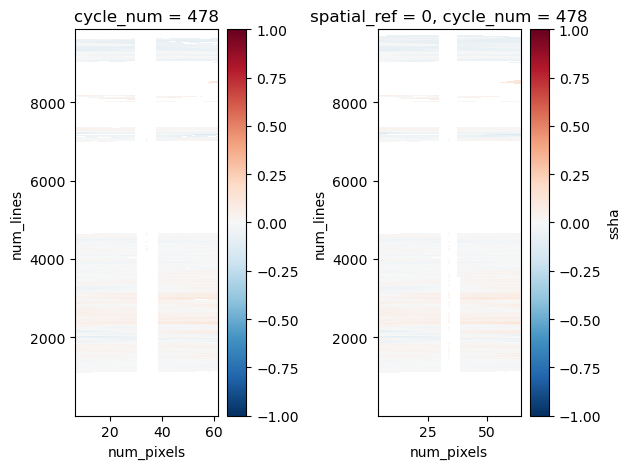

In [38]:
ageo = (1e-2*ds03.ssha_detided
        - low
       )
ic = 0
for cc in ageo.cycle_num:
    
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r03 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r03 = xr.concat([r03, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref:
        if ic == 0:
            a03 = ssha
        else:
            try:
                a03 = xr.concat([a03, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a03.coords["cycle_num"] = ("cycle_num",
                           r03.where(r03>0.7*r_ref, drop=True).cycle_num.data
                          )

dsa03 = a03.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa03.coords["y"] = ("y",range(len(dsa03.y)))
dsa03.coords["x"] = ("x",range(len(dsa03.x)))
if not dsa03.rio.crs:
    dsa03 = dsa03.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa03.ssha.rio.nodata is None:
    dsa03["ssha"] = dsa03.ssha.rio.write_nodata(np.nan)
_a03_exterp = dsa03.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha

a03_exterp = _a03_exterp.where(mm03.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds03.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )


fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
fig.set_tight_layout(True)

ageo.sel(cycle_num=478).isel(num_pixels=slice(inp,-inp)
                            ).plot(ax=ax1, rasterized=True, vmax=1e0)
a03_exterp.sel(cycle_num=478).plot(ax=ax2, rasterized=True, vmax=1e0)

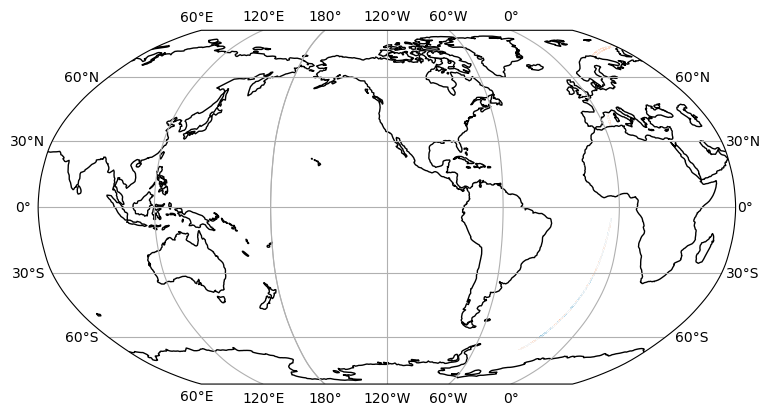

In [39]:
import cartopy.crs as ccrs
import cartopy.util as cutil

fig = plt.figure(figsize=(9,5))

# plot with central longitude 0
ax = fig.add_subplot(1, 1, 1,
                     projection=ccrs.Robinson(central_longitude=240)
                    )
ax.set_global()
ax.pcolormesh(long_adjusted, lati, 
              a03_exterp.isel(cycle_num=1),
              transform=ccrs.PlateCarree(), 
              cmap='RdBu',
              vmin=-.4, vmax=.4,
              rasterized=True)
ax.coastlines()
ax.gridlines(draw_labels=True)